In [11]:
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# %                   SCF-TB - PROXY APPLICATION                      %
# %                   A.M.N. Niklasson, M. Kulichenko. T1, LANL       %
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# % Total Energy Function:                                            %
# % E = 2Tr[H0(D-D0)] + (1/2)*sum_i U_i q_i^2 +                       %
# %      + (1/2)sum_{i,j (i!=j)} q_i C_{ij} q_j - Efield*dipole       %
# % dipole = sum_i R_{i} q_i                                          %
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
import torch
import numpy as np
import sys
import os
### path to PYSEQM ###
sys.path.insert(1, "/home/maxim/Projects/git2/PYSEQM_dev/")
from seqm.seqm_functions.read_xyz import read_xyz
import scipy.io as sio
import math
import pandas as pd
import importlib
import matplotlib.pyplot as plt

import dftorch
import importlib
import dftorch.CoulombMatrix
importlib.reload(dftorch.CoulombMatrix)
from dftorch.CoulombMatrix import CoulombMatrix_vectorized, Ewald_Real_Space_vectorized
from dftorch.SCF import SCF, SCF_adaptive_mixing

from dftorch.H0andS import H0_and_S_vectorized
from dftorch.Constants import Constants
from dftorch.nearestneighborlist import vectorized_nearestneighborlist
from dftorch.Energy import Energy
from dftorch.Tools import fractional_matrix_power_symm
from dftorch.Forces import Forces
from dftorch.BondIntegral import *
from dftorch.Tools import ordered_pairs_from_TYPE
from dftorch.Structure import Structure
from dftorch.DM_Fermi import DM_Fermi

import matplotlib.colors as mcolors

from dftorch.RepulsiveSpline import get_repulsion_energy
torch.set_default_dtype(torch.float64)
print(torch.cuda.memory_allocated() / 1e9, 'GB')

0.013891072 GB


In [12]:
%%time
# Initial data, load atoms and coordinates, etc in COORD.dat
device = 'cuda'
const = Constants().to(device)
Efield = 0*0.3*torch.tensor([-.3,0.4,0.0], device=device).T # In arbitrary direction  Works ony in 0-field!!!
Te = 3000.0                       # Some electronic temperature in Kelvin, Possible bug at high tempertures!!!

# species, coordinates = read_xyz(['3HDP_Ni.xyz'], sort=False) #Input coordinate file
# LBox = torch.tensor([60,61,62], device=device)

# species, coordinates = read_xyz(['protein.xyz'], sort=False) #Input coordinate file
# LBox = torch.tensor([100,100,100], device=device)

# species, coordinates = read_xyz(['COORD.xyz'], sort=False) #Input coordinate file
# LBox = torch.tensor([9,4,4], device=device)

species, coordinates = read_xyz(['COORD_H.xyz'], sort=False) #Input coordinate file
LBox = torch.tensor([90,40,40], device=device)

# species, coordinates = read_xyz(['COORD_Ni.xyz'], sort=False) #Input coordinate file
# LBox = torch.tensor([9,4,4], device=device)

# species, coordinates = read_xyz(['C2.xyz'], sort=False) #Input coordinate file
# LBox = torch.tensor([80,40,40], device=device)

# species, coordinates = read_xyz(['C840.xyz'], sort=False) #Input coordinate file
# LBox = torch.tensor([50,50,50], device=device) #36

# species, coordinates = read_xyz(['solvated_1600.xyz'], sort=False) #Input coordinate file
# LBox = torch.tensor([35,35,35], device=device)
#LBox = torch.tensor([100,100,100], device=device)

# species, coordinates = read_xyz(['gs_solvated_4k.xyz'], sort=False) #Input coordinate file
# LBox = torch.tensor([100,100,100], device=device)

req_grad = True
TYPE = torch.tensor(species[0], dtype=torch.int64, device=device)
RX = torch.tensor(coordinates[0,:,0], device=device, dtype=torch.get_default_dtype(),
                    requires_grad=req_grad)
RY = torch.tensor(coordinates[0,:,1], device=device, dtype=torch.get_default_dtype(),
                    requires_grad=req_grad)
RZ = torch.tensor(coordinates[0,:,2], device=device, dtype=torch.get_default_dtype(),
                    requires_grad=req_grad)
structure = Structure(TYPE, RX, RY, RZ, LBox, const, device=device)
# but first the neighborlist
R_tensor, R_orb, coeffs_tensor, R_rep_tensor, rep_splines_tensor = get_skf_tensors(TYPE, const)

nrnnlist, nndist, nnRx, nnRy, nnRz, nnType, nnStruct, nrnnStruct, \
        neighbor_I, neighbor_J, IJ_pair_type, JI_pair_type  = \
        vectorized_nearestneighborlist(structure.TYPE, structure.RX, structure.RY, structure.RZ, structure.LBox,
        5.6, structure.Nats, const, upper_tri_only=False, remove_self_neigh=False, min_image_only=False, verbose=True);
        
# Get Hamiltonian, Overlap, atomic DM = D0 (vector only), etc, 
D0, H0, dH0, S, dS = H0_and_S_vectorized(
                                structure.TYPE, structure.RX, structure.RY, structure.RZ, structure.LBox, structure.Nats,
                                structure.diagonal, structure.H_INDEX_START,structure.H_INDEX_END, structure.Znuc,
                                nrnnlist, nnRx, nnRy, nnRz, nnType,
                                const, neighbor_I, neighbor_J, IJ_pair_type, JI_pair_type,
                                R_orb, coeffs_tensor,
                                verbose=True)

Vr, dVr = get_repulsion_energy(
                        R_rep_tensor, rep_splines_tensor,
                        structure.TYPE, structure.RX, structure.RY, structure.RZ, structure.LBox, 4.9, structure.Nats,
                        const,verbose=True);

sk_orig/mio-1-1/mio-1-1/H-H.skf
sk_orig/mio-1-1/mio-1-1/H-C.skf
sk_orig/mio-1-1/mio-1-1/C-H.skf


sk_orig/mio-1-1/mio-1-1/C-C.skf
  t <neighbor list> 0.0 s

H0_and_S
  Do H diagonal
  t <diagonal> 0.0 s

  Do H off-diag
  t <dR and pair mask> 0.0 s

  t <SKF> 0.0 s

  Do H and S
  t <H and S> 0.0 s

  t <D0> 0.0 s

t 0.1 s

  t <neighbor list> 0.0 s

CPU times: user 2.49 s, sys: 35.1 ms, total: 2.52 s
Wall time: 394 ms


In [13]:
%%time
#Z = matrix_inverse_sqrt(S)  # Factorization Z of the inverse overlap matrix S. Z is the inverse square root of S
#Z0 = Z  # Z0 is the same as Z
#S0 = S  # Store S as S0

# Parameters for the Coulomb summations
Coulomb_acc = 1e-10
TIMERATIO = 10

COULVOL = LBox[0] * LBox[1] * LBox[2]
SQRTX = math.sqrt(-math.log(Coulomb_acc))
CALPHA = math.sqrt(math.pi) * ((TIMERATIO * structure.Nats / (COULVOL ** 2)) ** (1.0 / 6.0))
COULCUT = SQRTX / CALPHA
if COULCUT > 50.0:
    COULCUT = 50.0
    CALPHA = SQRTX / COULCUT

#Rcut = 10.42
Rcut = COULCUT


# Get full Coulomb matrix. In principle we do not need an explicit representation of the Coulomb matrix C!
nrnnlist, nndist, nnRx, nnRy, nnRz, nnType, nnStruct, \
nrnnStruct, neighbor_I, neighbor_J, IJ_pair_type, JI_pair_type = \
vectorized_nearestneighborlist( structure.TYPE, structure.RX, structure.RY, structure.RZ, structure.LBox, Rcut, structure.Nats, const,
                                upper_tri_only=False, remove_self_neigh=False, verbose=True)
                                
C, dCC, C_sr, dCC_sr = CoulombMatrix_vectorized(structure, structure.RX,structure.RY,structure.RZ,structure.LBox,
                                    structure.Hubbard_U, structure.Hubbard_U_sr, structure.TYPE,structure.Nats,
                                    structure.HDIM,Coulomb_acc,TIMERATIO,nnRx,nnRy,nnRz,nrnnlist,nnType, neighbor_I, neighbor_J,
                                    structure.H_INDEX_START,structure.H_INDEX_END)

  t <neighbor list> 0.0 s

CoulombMatrix_vectorized
  Do Coulomb Real
  Coulomb_Real t 0.0 s

  Doing Coulomb k
   LMAX: 13
   0
   1
   2
   3
   4
   5
   6
   7
   8
   9
   10
   11
   12
   13
  Coulomb_k t 0.4 s

CPU times: user 468 ms, sys: 10.1 ms, total: 478 ms
Wall time: 475 ms


In [14]:
# CC_real_orig, dCC_dxyz_real_orig = Ewald_Real_Space_vectorized(structure,
#                                 structure.RX, structure.RY, structure.RZ, dR, dR_dxyz, dist_mask, 
#                                 LBox, structure.Hubbard_U, structure.Hubbard_U_sr, structure.TYPE, structure.Nats, structure.HDIM,
#                                 Coulomb_acc, TIMERATIO, nnRx, nnRy, nnRz, nrnnlist, nnType,
#                                 structure.H_INDEX_START, structure.H_INDEX_END, CALPHA)

In [31]:
Z = fractional_matrix_power_symm(S, -0.5)
atom_ids = torch.repeat_interleave(torch.arange(len(structure.n_orbitals_per_atom), device=RX.device), structure.n_orbitals_per_atom) # Generate atom index for each orbital
atom_ids_sr = torch.repeat_interleave(torch.arange(len(structure.shell_types), device=RX.device), const.shell_dim[structure.shell_types]) # Generate atom index for each orbital
#atom_ids_sr = torch.repeat_interleave(torch.arange(len(structure.n_shells_per_atom), device=RX.device), structure.n_shells_per_atom) # Generate atom index for each orbital

Dorth, mu0 = DM_Fermi(Z.T @ H0 @ Z, Te, structure.Nocc, mu_0=None, m=18, eps=1e-9, MaxIt=50)
D = Z @ Dorth @ Z.T
DS = 2 * torch.diag(D @ S)


In [38]:
q = -1.0 * structure.Znuc
q.scatter_add_(0, atom_ids, DS) # sums elements from DS into q based on number of AOs, e.g. x4 p orbs for carbon or x1 for hydrogen

CoulPot = C @ q
Hcoul_diag = structure.Hubbard_U[atom_ids] * q[atom_ids] + CoulPot[atom_ids] 
Hcoul = 0.5 * (Hcoul_diag.unsqueeze(1) * S + S * Hcoul_diag.unsqueeze(0))


In [39]:
q = -1.0 * structure.Znuc

q.sum() 

tensor(-23., device='cuda:0')

In [42]:
S.diag().sum()

tensor(54.8274, device='cuda:0', grad_fn=<SumBackward0>)

In [43]:
S

tensor([[ 1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  4.2618e-01,
          3.8894e-01,  4.2618e-01,  4.4900e-01,  7.3896e-02,  1.1097e-01,
          6.1014e-03,  9.3909e-03,  2.5178e-01,  1.7371e-04,  4.9907e-04,
         -6.0573e-05, -4.4102e-05,  1.5957e-03,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00, -6.8615e-05],
        [ 0.0000e+00,  1.0000e+00,  0.0000e+00,  0.0000e+00, -1.9018e-01,
          2.7245e-01,  2.4092e-01, -3.3792e-01,  1.0611e-01,  1.2779e-01,
          9.7989e-03,  1.4720e-02,  2.6141e-01,  3.3997e-04,  7.8196e-04,
          3.4535e-05,  6.8557e-05,  2.6089e-03,  0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00, -3.6221e-05],
        [ 0.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00, -2.1811e-01,
          2.8499e-01, -2.8475e-01,  1.5199e-01,  0.0000e+00, -4.4658e-02,
          2.7993e-03, -3.9720e-03,  7.4552e-02,  0.0000e+00, -1.1857e-04,
          5.7129e-06, -1.0442e-05,  2.8247e-04,  0.0000e+00,  0.0000e+00,
          0.00

In [17]:
q_sr = -1.0 * structure.el_per_shell
q_sr.scatter_add_(0, atom_ids_sr, DS) # sums elements from DS into q based on number of AOs, e.g. x4 p orbs for carbon or x1 for hydrogen

CoulPot_sr = C_sr @ q_sr
Hcoul_diag_sr = structure.Hubbard_U_sr[atom_ids_sr] * q_sr[atom_ids_sr] + CoulPot_sr[atom_ids_sr] 
Hcoul_sr = 0.5 * (Hcoul_diag_sr.unsqueeze(1) * S + S * Hcoul_diag_sr.unsqueeze(0))
q_sr.shape, q_sr.sum()

(torch.Size([21]), tensor(-1.0000, device='cuda:0', grad_fn=<SumBackward0>))

In [37]:
q_sr = -1.0 * structure.el_per_shell
q_sr.sum()

tensor(-23., device='cuda:0')

In [19]:
q_sr

tensor([-2., -2., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
        -1., -1., -1., -1., -1., -1., -1.], device='cuda:0')

In [25]:
#with torch.no_grad():
H, Hcoul, Hdipole, D, q, q_sr, f = SCF(structure,
        H0, S, Efield, C, C_sr,
        structure.TYPE, structure.RX, structure.RY, structure.RZ,
        structure.H_INDEX_START, structure.H_INDEX_END,
        structure.Nocc, structure.Hubbard_U, structure.Znuc, structure.Nats, Te, const,
        alpha=0.1,
        acc=5e-7, MAX_ITER=100, debug=False)

Etot,Eband0,Ecoul,Edipole,S_ent = Energy(H0, structure.Hubbard_U, Efield, D0, C, D, q,
                                            structure.RX, structure.RY, structure.RZ, f, Te) # Energy calculation - 2*Te*S_ent
Etot+Vr ,Eband0,Ecoul,Edipole,S_ent, Vr

### Do SCF ###
  Initial DM_Fermi

Starting cycle
Iter 1
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
tensor(-1.0000, device='cuda:0')
tensor(-1.0000, device='cuda:0')
  update q 0.0 s
Res = 2.070753164, dEb = 187.766103148, dEc = 4.517948731, t = 0.0 s

Res_sr = 2.562285698, t = 0.0 s

Iter 2
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
tensor(-1.0000, device='cuda:0')
tensor(-1.0000, device='cuda:0')
  update q 0.0 s
Res = 1.326860645, dEb = 5.333007745, dEc = 0.620519329, t = 0.0 s

Res_sr = 1.939643261, t = 0.0 s

Iter 3
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
tensor(-1.0000, device='cuda:0')
tensor(-1.0000, device='cuda:0')
  update q 0.0 s
Res = 0.931684679, dEb = 1.481451578, dEc = 0.312932489, t = 0.0 s

Res_sr = 1.463361555, t = 0.0 s

Iter 4
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
tensor(-1.0000, device='cuda:0')
tensor(-1.0000, device='cuda:0')
  update q 0.0 s
Res = 0.606976881, dEb = 0.730322045, dEc = 0.167824227, t = 0.0 s

Res_sr = 1.09

(tensor(-194.0126, device='cuda:0', grad_fn=<AddBackward0>),
 tensor(-196.0961, device='cuda:0', grad_fn=<MulBackward0>),
 tensor(3.0179, device='cuda:0', grad_fn=<AddBackward0>),
 tensor(-0., device='cuda:0', grad_fn=<NegBackward0>),
 tensor(0.0001, device='cuda:0'),
 tensor(-0.0907, device='cuda:0', grad_fn=<MulBackward0>))

In [26]:
q.sum()

tensor(-1.0000, device='cuda:0', grad_fn=<SumBackward0>)

In [27]:
q_sr.sum()

tensor(-1.0000, device='cuda:0')

In [5]:
Eband0/27.21138625, Ecoul/27.21138625, Vr/27.21138625

(tensor(-12.1475, device='cuda:0', grad_fn=<DivBackward0>),
 tensor(0.0088, device='cuda:0', grad_fn=<DivBackward0>),
 tensor(-0.0093, device='cuda:0', grad_fn=<DivBackward0>))

In [27]:
Eband0/27.21138625, Ecoul/27.21138625, Vr/27.21138625

(tensor(-12.1475, device='cuda:0', grad_fn=<DivBackward0>),
 tensor(0.0088, device='cuda:0', grad_fn=<DivBackward0>),
 tensor(-0.0093, device='cuda:0', grad_fn=<DivBackward0>))

In [28]:
True & False

False

In [15]:
%%time
with torch.no_grad():
    Ftot, Fcoul, Fband0, Fdipole, FPulay, FScoul, FSdipole, Frep = \
    Forces( H, H0, S, C,
            D, D0,
            dH0, dS, dCC, dVr,
            Efield, structure.Hubbard_U, q,
            structure.RX, structure.RY, structure.RZ,
            structure.Nats, structure.H_INDEX_START, structure.H_INDEX_END, const, structure.TYPE)
#torch.save(Ftot, 'Ftot_840_f64.pt')
Ftot

Doing Fcoul
Doing Fband0
Doing Pulay
Doing Fdipole
Doing FScoul
Doing FSdipole
Doing Repulsion
CPU times: user 4.46 s, sys: 21 ms, total: 4.48 s
Wall time: 4.45 s


tensor([[ 0.6583, -0.5236,  0.0198,  ...,  0.2259,  0.5575, -1.1288],
        [ 0.0304, -0.3947,  0.0580,  ..., -0.8766,  0.2149, -0.8152],
        [-0.2033, -0.1986,  0.0144,  ...,  0.0798, -0.2549,  0.3117]],
       device='cuda:0')

In [20]:
abs(torch.load('Ftot_840_f64.pt') - torch.load('Ftot_840_f32.pt')).max()

tensor(0.0004, device='cuda:0')

In [7]:
diff = abs(torch.load('Ftot_840_f64.pt') - torch.load('Ftot_840_f32.pt')).cpu().numpy()
diff.flatten()

array([1.97357937e-04, 1.03743431e-04, 1.29279232e-05, 1.04662626e-04,
       2.30386161e-05, 1.80154517e-04, 2.19103542e-04, 3.59453102e-05,
       6.29167261e-05, 6.15298368e-05, 1.25011460e-04, 1.01693515e-04,
       2.22454994e-04, 1.91496068e-05, 7.27657432e-05, 1.60094022e-04,
       1.94323284e-04, 2.64467642e-04, 1.66042527e-04, 7.98240408e-05,
       1.33870542e-04, 1.11940194e-04, 1.09445449e-04, 4.73589619e-05,
       1.58789533e-04, 1.46899313e-04, 7.18541246e-05, 1.47268570e-04,
       7.54366910e-05, 5.66614087e-05, 1.65332392e-04, 1.11226667e-04,
       1.19656748e-04, 4.71979338e-05, 4.51779831e-05, 2.48707281e-04,
       1.31252008e-04, 3.63467612e-06, 1.49427308e-04, 1.28080823e-04,
       2.90474632e-04, 1.07199271e-04, 3.08649395e-04, 4.48266347e-05,
       3.82841493e-04, 2.05525549e-04, 5.41850501e-05, 1.38303564e-04,
       2.11235616e-05, 1.30249186e-04, 1.38051214e-04, 3.45982308e-04,
       1.46897160e-04, 7.15873398e-05, 6.47881841e-06, 2.62017778e-04,
      

(array([66., 70., 73., 65., 78., 73., 61., 63., 67., 76., 61., 59., 67.,
        53., 65., 62., 51., 42., 61., 39., 44., 52., 37., 45., 53., 44.,
        53., 41., 42., 35., 38., 29., 33., 39., 32., 33., 30., 33., 33.,
        26., 21., 24., 21., 16., 32., 15., 23., 27., 25., 21., 19., 16.,
        21., 14., 13.,  9., 11., 14., 11.,  6., 17.,  6., 13.,  6., 11.,
         7.,  8.,  5.,  5.,  6., 10.,  8.,  1.,  7.,  4.,  0.,  2.,  2.,
         0.,  3.,  1.,  1.,  1.,  0.,  0.,  1.,  0.,  2.,  1.,  2.,  0.,
         0.,  0.,  0.,  1.,  3.,  0.,  1.,  1.,  1.]),
 array([3.13242823e-08, 4.38297811e-06, 8.73463194e-06, 1.30862858e-05,
        1.74379396e-05, 2.17895934e-05, 2.61412473e-05, 3.04929011e-05,
        3.48445549e-05, 3.91962088e-05, 4.35478626e-05, 4.78995164e-05,
        5.22511702e-05, 5.66028241e-05, 6.09544779e-05, 6.53061317e-05,
        6.96577856e-05, 7.40094394e-05, 7.83610932e-05, 8.27127471e-05,
        8.70644009e-05, 9.14160547e-05, 9.57677085e-05, 1.00119362e-04,
  

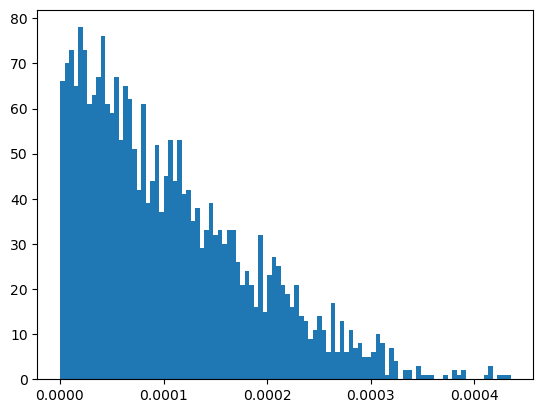

In [8]:
plt.hist(diff.flatten(), bins=100)

In [6]:
Etot+Vr + 2 * Te * S_ent

tensor(-317.8148, device='cuda:0', grad_fn=<AddBackward0>)

In [7]:
Eband0 + Ecoul + Vr

tensor(-317.8148, device='cuda:0', grad_fn=<AddBackward0>)

In [8]:
%%time
Ftot, Fcoul, Fband0, Fdipole, FPulay, FScoul, FSdipole, Frep = \
Forces( H.to(torch.float64), H0.to(torch.float64), S.to(torch.float64), C.to(torch.float64),
        D.to(torch.float64), D0.to(torch.float64),
        dH0.to(torch.float64), dS.to(torch.float64), dCC.to(torch.float64), dVr,
        Efield, structure.Hubbard_U, q.to(torch.float64),
        structure.RX.to(torch.float64), structure.RY.to(torch.float64), structure.RZ.to(torch.float64),
        structure.Nats, structure.H_INDEX_START, structure.H_INDEX_END, const, structure.TYPE)
#torch.save(Ftot, 'Ftot_840.pt')

Doing Fcoul
Doing Fband0
Doing Pulay
Doing Fdipole
Doing FScoul
Doing FSdipole
Doing Repulsion
CPU times: user 6.99 s, sys: 476 ms, total: 7.46 s
Wall time: 7.45 s


In [10]:
(Etot).backward()
force = -structure.RX.grad
force


tensor([ 9.2077e-01, -7.0236e-01,  1.1492e+00,  5.5958e-01,  3.1920e+00,
         1.7018e-02,  3.8230e-03,  7.8820e-01,  1.0193e+00,  4.9577e-01,
         8.0091e-01,  3.2337e-01, -7.7551e-01, -2.4500e+00, -3.7349e-01,
        -5.5929e-01,  3.6076e-01,  4.4714e-01,  3.6467e-01,  3.6536e-02,
        -5.4226e-01,  5.6050e-01,  2.2491e-01, -3.6718e-01,  3.6226e-01,
         3.4375e-01, -1.4787e-01,  2.6806e-01,  2.4662e-01,  1.0586e-01,
        -1.7754e-01, -9.1957e-01,  1.3327e-01, -8.0209e-01,  9.5970e-01,
         3.8801e-01, -7.5964e-01, -2.6744e+00,  3.0402e-01, -2.4668e-01,
        -2.2758e-01, -1.0119e-02,  6.1603e-01,  1.8394e-01, -2.9868e-01,
        -2.6523e-03, -2.7763e-01, -2.2288e-01, -6.5372e-03, -7.7128e-01,
         2.6057e-01,  7.7069e-02,  2.7025e-01,  4.5177e-01,  9.4380e-03,
         3.5432e-01,  4.6743e-01, -2.4321e-01, -1.6163e-01,  8.4602e-02,
        -8.5271e-01,  1.9653e-01, -3.5229e-01, -9.7095e-02, -4.4730e-01,
        -6.8636e-01, -4.5258e-01, -4.9454e-01, -2.3

In [17]:
Ftot[0] - (force+Frep[0])

tensor([-1.8320e-10,  1.2222e-10, -1.8348e-10, -2.0639e-10,  2.2004e-10,
         3.5227e-11,  1.4426e-10, -1.8013e-10, -1.9843e-10,  1.9419e-10,
         6.0550e-11,  1.5584e-10, -3.9334e-10, -2.8792e-10,  1.6882e-10,
         3.2570e-10,  2.2426e-10, -2.7932e-10, -1.8649e-10,  4.4757e-10],
       device='cuda:0')

In [ ]:
Ftot[0] - (force+Frep[0])

tensor([-1.8986e-07,  1.3036e-07, -2.2242e-07, -2.4158e-07,  2.3786e-07,
         4.1027e-08,  1.5282e-07, -1.8738e-07, -2.0717e-07,  2.0379e-07,
         2.2075e-08,  1.7123e-07, -3.8276e-07, -2.6839e-07,  2.2549e-07,
         3.1347e-07,  2.1357e-07, -2.6091e-07, -1.7336e-07,  4.2214e-07],
       device='cuda:0')

In [12]:
FPulay[0]

tensor([-65.3018,  -0.5770,  82.2608,  ..., -66.2514, 158.8680, -93.9754],
       device='cuda:0')

In [7]:
Ftot[0] - Frep[0] - force, (Ftot[0] - Frep[0] - force).abs().sum()

(tensor([ 1.5935e-05, -8.8818e-06, -1.2341e-05,  7.5785e-06, -4.4975e-06,
          5.3312e-05, -5.8716e-06,  1.3848e-05,  7.6837e-06, -2.1376e-05,
         -6.2628e-05, -5.5593e-06, -6.2985e-06, -5.1848e-06,  4.1773e-05,
          1.3621e-05, -2.1672e-05,  1.7806e-05,  1.2194e-05, -2.7932e-05],
        device='cuda:0', dtype=torch.float64, grad_fn=<SubBackward0>),
 tensor(0.0004, device='cuda:0', dtype=torch.float64, grad_fn=<SumBackward0>))

In [19]:
Ftot[0] - Frep[0] - force, (Ftot[0] - Frep[0] - force).abs().sum()

(tensor([ 3.0928e-05, -6.9553e-06,  4.7472e-05,  1.0365e-05, -2.6098e-05,
         -5.2694e-05,  1.3428e-05,  4.3690e-05,  2.7282e-05, -3.9029e-05,
         -6.6047e-05,  4.4677e-06,  2.5218e-05, -1.3136e-05,  6.1652e-05,
         -3.8240e-05,  5.7365e-06,  1.0822e-05,  3.3094e-05, -4.5830e-05],
        device='cuda:0', dtype=torch.float64, grad_fn=<SubBackward0>),
 tensor(0.0006, device='cuda:0', dtype=torch.float64, grad_fn=<SumBackward0>))

In [6]:
(Eband0).backward()
force = -structure.RX.grad
force


tensor([-8.4395,  1.6558, -8.4185, -6.1870,  3.8074, -0.4504,  3.1457, -7.9513,
        -5.5270, 10.8899, -0.7190,  3.2231, -8.0076, -5.4663, 10.8417,  7.7009,
         3.8563, -3.0656, -2.0972, 11.2086], device='cuda:0')

In [6]:
Eband0 = 2 * torch.trace(H0 @ D)

Z = fractional_matrix_power_symm(S, -0.5)
Eband_S = 2 * torch.trace((Z.T @ H0 @ Z) @ D)
# forward equals Eband0, grads come from Eband_S
Eband = Eband0.detach() + (Eband_S - Eband_S.detach())


In [8]:
Fband0[0]

tensor([ -7.7177,   5.2258, -13.8036, -10.9137,   9.4956,  -0.1819,   6.9819,
        -13.1983, -10.2476,  16.9382,  -0.6895,   7.0189, -13.2905, -10.2433,
         16.8836,   7.3797,   7.6471,  -8.3820,  -6.2389,  17.3363],
       device='cuda:0', grad_fn=<SelectBackward0>)

In [9]:
FPulay[0]

tensor([-0.7920, -3.5343,  5.4039,  4.7734, -5.6280, -0.2774, -3.8615,  5.2932,
         4.7607, -6.0862, -0.0952, -3.8168,  5.2163,  4.7206, -6.0390,  0.3846,
        -3.7335,  5.1741,  4.0546, -5.9176], device='cuda:0',
       grad_fn=<SelectBackward0>)

In [11]:
Fband0[0] + FPulay[0] - force

tensor([-0.0702,  0.0357,  0.0188,  0.0468,  0.0601, -0.0089, -0.0253,  0.0462,
         0.0402, -0.0379, -0.0657, -0.0209, -0.0666, -0.0564,  0.0028,  0.0634,
         0.0572, -0.1423, -0.0872,  0.2101], device='cuda:0',
       grad_fn=<SubBackward0>)

In [ ]:
force

In [20]:
FPulay[0] - Fband0[0]

tensor([-49.4246, -63.1221,  55.0636,  ...,  -9.5910,  19.2789,  -9.7912],
       device='cuda:0', grad_fn=<SubBackward0>)

In [49]:
Ftot[0]

tensor([ 0.7064,  1.8521, -1.6259,  ..., -0.0981, -0.0126, -0.0376],
       device='cuda:0', dtype=torch.float64, grad_fn=<SelectBackward0>)

In [8]:
print((Fband0+FPulay+FScoul) * 0.0367493 / 1.8897161646321,
      Ftot[0,0].item()* 0.0367493 / 1.8897161646321 + 0.0049233671,
        (Fband0+FPulay+FScoul)[0,0].item() * 0.0367493 / 1.8897161646321 - 0.2447458460,
        Fcoul[0,0].item() * 0.0367493 / 1.8897161646321 - 0.0095567549,
        Frep[0,0].item()* 0.0367493 / 1.8897161646321 + 0.2592259680)

tensor([[ 0.2447,  0.3315, -0.2913,  ...,  0.0457, -0.1086,  0.0605],
        [ 0.1847, -0.0152, -0.1070,  ...,  0.1833, -0.0534, -0.1325],
        [ 0.0501, -0.0733,  0.1514,  ..., -0.0529,  0.1009, -0.0597]],
       device='cuda:0', dtype=torch.float64) -1.963742850511537e-05 -1.7236651963653538e-05 -1.7871987388028143e-06 -6.135778026217231e-07


-2.5894952418621664e-05

In [ ]:
dt = torch.float32
torch.set_default_dtype(dt)
H, Hcoul, Hdipole, D, q, f = SCF(
    H0.to(dt), S.to(dt), Efield.to(dt), C.to(dt), 
    structure.TYPE, structure.RX.to(dt), structure.RY.to(dt), structure.RZ.to(dt),
    structure.H_INDEX_START, structure.H_INDEX_END,
    Nocc, Hubbard_U.to(dt), structure.Znuc, Nats, Te, const,
    alpha=0.08,
    acc=1e-6, MAX_ITER=200, debug=True)

Etot,Eband0,Ecoul,Edipole,S_ent = Energy(H0.to(dt), Hubbard_U.to(dt), Efield, D0, C.to(dt), D, q,
                                         RX, RY, RZ, f, Te) # Energy calculation - 2*Te*S_ent
Etot ,Eband0,Ecoul,Edipole,S_ent

### Do SCF ###
  Initial DM_Fermi

Starting cycle
Iter 1
  Hcoul 0.0 s
  DM_Fermi 36.0 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 6.858121395, t = 36.1 s

Iter 2
  Hcoul 0.0 s
  DM_Fermi 36.5 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 6.023651123, t = 36.5 s

Iter 3
  Hcoul 0.0 s
  DM_Fermi 38.2 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 5.306811333, t = 38.2 s

Iter 4
  Hcoul 0.0 s
  DM_Fermi 39.5 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 4.686926842, t = 39.5 s

Iter 5
  Hcoul 0.0 s
  DM_Fermi 39.5 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 4.150836468, t = 39.5 s

Iter 6
  Hcoul 0.0 s


In [7]:
Znuc.dtype

torch.int64

In [19]:
(torch.tensor([Eband0, Ecoul, Edipole, S_ent, Vr])/27.21138625).sum()

tensor(-2237.3450)

In [20]:
(torch.tensor([Eband0, Ecoul, Edipole, S_ent, Vr])/27.21138625)

tensor([-2.2896e+03,  9.4355e+00, -0.0000e+00,  1.0240e-05,  4.2821e+01])

In [24]:
Vr

tensor(42.8210, device='cuda:0')

In [17]:
Etot - Vr

tensor(-62090.9688, device='cuda:0')

In [31]:
# CUDA
# Iter 3
#   Hcoul 0.0 s
#   DM_Fermi 1.7 s
#   Z@Dorth@Z.T 0.5 s
#   update q 0.0 s
# Res = 4.961360190, t = 2.3 s

# CPU
# Iter 3
#   Hcoul 0.1 s
#   DM_Fermi 1.2 s
#   Z@Dorth@Z.T 0.3 s
#   update q 0.0 s
# Res = 4.961359501, t = 1.5 s

In [18]:
H, Hcoul, Hdipole, D, q, f = SCF_adaptive_mixing(
    H0, S, Efield, C, 
    TYPE, RX, RY, RZ,
    H_INDEX_START, H_INDEX_END,
    Nocc, Hubbard_U, Znuc, Nats, Te, const,
    mixing="anderson", anderson_m=2, anderson_lam=1e-10, anderson_damp=0.12,
    #mixing="adaptive", alpha0=0.1, alpha_min=0.0051, alpha_max=0.5,
    acc=1e-8, MAX_ITER=80)

Etot,Eband0,Ecoul,Edipole,S_ent = Energy(H0, Hubbard_U, Efield, D0, C, D, q,
                                         RX, RY, RZ, f, Te) # Energy calculation - 2*Te*S_ent
Etot + Vr ,Eband0,Ecoul,Edipole,S_ent

### Do SCF (adaptive mixing) ###
  Initial DM_Fermi

Starting cycle
Iter 1
  Hcoul 0.000 s
  DM_Fermi 0.303 s
  Z@Dorth@Z.T 0.000 s
  mix: method=anderson, Res=6.862e+00, Anderson m=2, damp=0.12
  update q 0.019 s
  iter wall 0.323 s

Iter 2
  Hcoul 0.000 s
  DM_Fermi 0.306 s
  Z@Dorth@Z.T 0.000 s
  mix: method=anderson, Res=5.617e+00, Anderson m=2, damp=0.12
  update q 0.019 s
  iter wall 0.326 s

Iter 3
  Hcoul 0.000 s
  DM_Fermi 0.255 s
  Z@Dorth@Z.T 0.000 s
  mix: method=anderson, Res=4.107e+00, Anderson m=2, damp=0.12
  update q 0.020 s
  iter wall 0.275 s

Iter 4
  Hcoul 0.000 s
  DM_Fermi 0.308 s
  Z@Dorth@Z.T 0.000 s
  mix: method=anderson, Res=3.051e+00, Anderson m=2, damp=0.12
  update q 0.019 s
  iter wall 0.328 s

Iter 5
  Hcoul 0.000 s
  DM_Fermi 0.302 s
  Z@Dorth@Z.T 0.000 s
  mix: method=anderson, Res=2.223e+00, Anderson m=2, damp=0.12
  update q 0.019 s
  iter wall 0.322 s

Iter 6
  Hcoul 0.000 s
  DM_Fermi 0.305 s
  Z@Dorth@Z.T 0.000 s
  mix: method=anderson, Res=1.628

(tensor(-60882.9297, device='cuda:0'),
 -62303.23046875,
 256.75244140625,
 -0.0,
 0.00027863512514159083)

In [ ]:
H, Hcoul, Hdipole, D, q, f = SCF_adaptive_mixing(
    H0.to(torch.float64), S.to(torch.float64), Efield.to(torch.float64), C.to(torch.float64), 
    TYPE, RX.to(torch.float64), RY.to(torch.float64), RZ.to(torch.float64),
    H_INDEX_START, H_INDEX_END,
    Nocc, Hubbard_U, Znuc, Nats, Te, const,
    mixing="anderson", anderson_m=2, anderson_lam=1e-10, anderson_damp=0.125,
    #mixing="adaptive", alpha0=0.1, alpha_min=0.0051, alpha_max=0.5,
    acc=1e-8, MAX_ITER=80)

Etot,Eband0,Ecoul,Edipole,S_ent = Energy(H0.to(torch.float64), Hubbard_U, Efield, D0, C.to(torch.float64), D, q,
                                         RX, RY, RZ, f, Te) # Energy calculation - 2*Te*S_ent
Etot + Vr ,Eband0,Ecoul,Edipole,S_ent

### Do SCF (adaptive mixing) ###
  Initial DM_Fermi

Starting cycle
Iter 1
  Hcoul 0.003 s
  DM_Fermi 1.430 s
  Z@Dorth@Z.T 0.000 s
  mix: method=anderson, Res=6.863e+00, Anderson m=2, damp=0.12
  update q 0.792 s
  iter wall 2.224 s

Iter 2
  Hcoul 0.001 s
  DM_Fermi 1.438 s
  Z@Dorth@Z.T 0.000 s
  mix: method=anderson, Res=5.567e+00, Anderson m=2, damp=0.12
  update q 0.809 s
  iter wall 2.247 s

Iter 3
  Hcoul 0.001 s
  DM_Fermi 1.441 s
  Z@Dorth@Z.T 0.000 s
  mix: method=anderson, Res=4.013e+00, Anderson m=2, damp=0.12
  update q 0.796 s
  iter wall 2.238 s

Iter 4
  Hcoul 0.001 s
  DM_Fermi 1.442 s
  Z@Dorth@Z.T 0.000 s
  mix: method=anderson, Res=2.943e+00, Anderson m=2, damp=0.12
  update q 0.796 s
  iter wall 2.239 s

Iter 5
  Hcoul 0.000 s
  DM_Fermi 1.444 s
  Z@Dorth@Z.T 0.000 s
  mix: method=anderson, Res=2.113e+00, Anderson m=2, damp=0.12
  update q 0.796 s
  iter wall 2.241 s

Iter 6
  Hcoul 0.001 s
  DM_Fermi 1.447 s
  Z@Dorth@Z.T 0.000 s
  mix: method=anderson, Res=1.526

KeyboardInterrupt: 

In [ ]:
# Iter 38
#   Hcoul 0.059 s
#   DM_Fermi 1.376 s
#   Z@Dorth@Z.T 0.261 s
#   mix: method=anderson, Res=3.813e-05, Anderson m=2, damp=0.12
#   update q 0.018 s
#   iter wall 1.715 s

# Iter 29
#   Hcoul 0.001 s
#   DM_Fermi 1.553 s
#   Z@Dorth@Z.T 0.000 s
#   mix: method=anderson, Res=6.975e-04, Anderson m=2, damp=0.12
#   update q 0.839 s
#   iter wall 2.392 s

In [10]:
%%time
Ftot, Fcoul, Fband0, Fdipole, FPulay, FScoul, FSdipole, Frep = Forces(H.to(torch.float64), H0.to(torch.float64),
                                                                S.to(torch.float64), C.to(torch.float64), D.to(torch.float64), D0.to(torch.float64),
                                                                dH0.to(torch.float64), dS.to(torch.float64),
                   dCC.to(torch.float64), dVr, Efield, Hubbard_U, q.to(torch.float64), RX.to(torch.float64), RY.to(torch.float64), RZ.to(torch.float64),
                   Nats, H_INDEX_START, H_INDEX_END, const, TYPE)
#torch.save(Ftot, 'Ftot_840.pt')

Doing Fcoul
Doing Fband0
Doing Pulay
Doing Fdipole
Doing FScoul
Doing FSdipole
Doing Repulsion
CPU times: user 3.86 s, sys: 26 ms, total: 3.89 s
Wall time: 3.88 s


In [11]:
(Fband0+FPulay+FScoul) * 0.0367493 / 1.8897161646321

tensor([[ 0.2447,  0.3315, -0.2914,  ...,  0.0457, -0.1086,  0.0605],
        [ 0.1847, -0.0152, -0.1070,  ...,  0.1833, -0.0534, -0.1325],
        [ 0.0501, -0.0733,  0.1515,  ..., -0.0529,  0.1009, -0.0597]],
       device='cuda:0', dtype=torch.float64)

In [12]:
Ftot[0,0].item()* 0.0367493 / 1.8897161646321 + 0.0049233671

-2.5894952418621664e-05

In [13]:
(Fband0+FPulay+FScoul)[0,0].item() * 0.0367493 / 1.8897161646321 - 0.2447458460

-2.334854628210925e-05

In [14]:
Fcoul[0,0].item() * 0.0367493 / 1.8897161646321 - 0.0095567549

-1.932828333892425e-06

In [15]:
Frep[0,0].item()* 0.0367493 / 1.8897161646321 + 0.2592259680

-6.135778026217231e-07

In [5]:
H, Hcoul, Hdipole, D, q, f = SCF(
    H0.to(torch.float64), S.to(torch.float64), Efield.to(torch.float64), C.to(torch.float64), 
    TYPE, RX.to(torch.float64), RY.to(torch.float64), RZ.to(torch.float64),
    H_INDEX_START, H_INDEX_END,
    Nocc, Hubbard_U, Znuc, Nats, Te, const,
    alpha=0.1,
    acc=1e-6, MAX_ITER=5, debug=True)

Etot,Eband0,Ecoul,Edipole,S_ent = Energy(H0.to(torch.float64), Hubbard_U, Efield, D0, C.to(torch.float64), D, q,
                                         RX, RY, RZ, f, Te) # Energy calculation - 2*Te*S_ent
Etot + E_rep ,Eband0,Ecoul,Edipole,S_ent

### Do SCF ###
  Initial DM_Fermi

Starting cycle
Iter 1
  Hcoul 0.1 s
  DM_Fermi 1.2 s
  Z@Dorth@Z.T 0.3 s
  update q 0.0 s
Res = 6.863282146, t = 1.8 s

Iter 2
  Hcoul 0.1 s
  DM_Fermi 1.2 s
  Z@Dorth@Z.T 0.3 s
  update q 0.0 s
Res = 5.822525386, t = 1.5 s

Iter 3
  Hcoul 0.1 s
  DM_Fermi 1.2 s
  Z@Dorth@Z.T 0.3 s
  update q 0.0 s
Res = 4.961359501, t = 1.5 s

Iter 4
  Hcoul 0.1 s
  DM_Fermi 1.2 s
  Z@Dorth@Z.T 0.3 s
  update q 0.0 s
Res = 4.247873023, t = 1.6 s

Iter 5
Did not converge
  Hcoul 0.1 s


KeyboardInterrupt: 

In [ ]:
# CUDA
# Iter 3
#   Hcoul 0.0 s
#   DM_Fermi 1.7 s
#   Z@Dorth@Z.T 0.5 s
#   update q 0.0 s
# Res = 4.961360190, t = 2.3 s

# CPU
# Iter 3
#   Hcoul 0.1 s
#   DM_Fermi 1.2 s
#   Z@Dorth@Z.T 0.3 s
#   update q 0.0 s
# Res = 4.961359501, t = 1.5 s

In [8]:
H0.shape

torch.Size([3422, 3422])

In [ ]:
H, Hcoul, Hdipole, D, q, f = SCF(
    H0.to(torch.float64), S.to(torch.float64), Efield.to(torch.float64), C.to(torch.float64), 
    TYPE, RX.to(torch.float64), RY.to(torch.float64), RZ.to(torch.float64),
    H_INDEX_START, H_INDEX_END,
    Nocc, Hubbard_U, Znuc, Nats, Te, const,
    alpha = 0.2,
    acc=1e-6, MAX_ITER=100)

Etot,Eband0,Ecoul,Edipole,S_ent = Energy(H0.to(torch.float64), Hubbard_U, Efield, D0, C.to(torch.float64), D, q,
                                         RX, RY, RZ, f, Te) # Energy calculation - 2*Te*S_ent
Etot,Eband0,Ecoul,Edipole,S_ent

### Do SCF ###
  Initial DM_Fermi

Starting cycle
Iter 1
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 0.197195926, t = 0.0 s

Iter 2
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 0.151282408, t = 0.0 s

Iter 3
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 0.116063264, t = 0.0 s

Iter 4
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 0.089046224, t = 0.0 s

Iter 5
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 0.068320254, t = 0.0 s

Iter 6
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 0.052419854, t = 0.0 s

Iter 7
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 0.040221094, t = 0.0 s

Iter 8
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 0.030861941, t = 0.0 s

Iter 9
  Hcoul 0.0 s
  DM_Fermi 0.0 s
  Z@Dorth@Z.T 0.0 s
  update q 0.0 s
Res = 0.023681194, t = 0.0 s

Iter 

(-323.7498723525707,
 -324.0130469058701,
 0.2632593421623106,
 -0.0,
 1.4131477155516542e-08)